# 03 — Quote Staleness Under Rate Changes

This notebook studies quote/execution mismatch when a rate-dependent asset changes value between quote and execution.

The goal is to visualize one StableSwap NG integration risk:

> A quote can be internally correct at the time it is computed, but become stale if an oracle rate or ERC4626 share price changes before execution.

This notebook models a simplified 2-coin pool:

- coin0 has fixed rate = `1e18`
- coin1 has changing rate
- quote is computed using old rates
- execution is computed using updated rates

Security relevance:

- rate-dependent assets introduce quote freshness assumptions;
- integrators should not treat a quote as state-independent;
- stale quote direction depends on whether the changing-rate token is input or output.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from curve_stableswap_lab.scenarios import quote_staleness_rate_change_grid
from curve_stableswap_lab.stableswap_math import A_PRECISION, PRECISION

In [3]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FIGURE_DIR = ROOT / "outputs" / "figures"
TABLE_DIR = ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
amp = 100 * A_PRECISION

balances = [
    10**18,
    10**18,
]

base_rates = [
    PRECISION,
    PRECISION,
]

dx = 10**15
fee = 0

rate_changes = [
    0.90,
    0.95,
    0.98,
    0.99,
    1.00,
    1.01,
    1.02,
    1.05,
    1.10,
]

In [5]:
df = quote_staleness_rate_change_grid(
    rate_changes=rate_changes,
    amp=amp,
    balances=balances,
    base_rates=base_rates,
    dx=dx,
    fee=fee,
)

df.head()

,direction,rate_change,quoted_dy,executed_dy,error,error_pct_of_quote,abs_error,abs_error_pct_of_quote
0,output_rate_changes,0.90,999990099098224,1109935625510940,-109945526412716,-0.109947,109945526412716,0.109947
1,input_rate_changes,0.90,999990099098224,900935018519665,99055080578559,0.099056,99055080578559,0.099056
2,output_rate_changes,0.95,999990099098224,1052085833630605,-52095734532381,-0.052096,52095734532381,0.052096
3,input_rate_changes,0.95,999990099098224,950473896327092,49516202771132,0.049517,49516202771132,0.049517
4,output_rate_changes,0.98,999990099098224,1020193832218389,-20203733120165,-0.020204,20203733120165,0.020204


In [6]:
plot_df = df.copy()

plot_df["rate_change_pct"] = (plot_df["rate_change"] - 1.0) * 100
plot_df["error_pct_display"] = plot_df["error_pct_of_quote"] * 100
plot_df["abs_error_pct_display"] = plot_df["abs_error_pct_of_quote"] * 100

plot_df[
    [
        "direction",
        "rate_change",
        "rate_change_pct",
        "quoted_dy",
        "executed_dy",
        "error",
        "error_pct_display",
    ]
]

,direction,rate_change,rate_change_pct,quoted_dy,executed_dy,error,error_pct_display
0,output_rate_changes,0.90,-10.0,999990099098224,1109935625510940,-109945526412716,-10.994661
1,input_rate_changes,0.90,-10.0,999990099098224,900935018519665,99055080578559,9.905606
2,output_rate_changes,0.95,-5.0,999990099098224,1052085833630605,-52095734532381,-5.209625
3,input_rate_changes,0.95,-5.0,999990099098224,950473896327092,49516202771132,4.951669
4,output_rate_changes,0.98,-2.0,999990099098224,1020193832218389,-20203733120165,-2.020393
5,input_rate_changes,0.98,-2.0,999990099098224,980186465377924,19803633720300,1.980383
6,output_rate_changes,0.99,-1.0,999990099098224,1009990446190332,-10000347092108,-1.000045
7,input_rate_changes,0.99,-1.0,999990099098224,990088766803433,9901332294791,0.990143
8,output_rate_changes,1.00,0.0,999990099098224,999990099098224,0,0.000000
9,input_rate_changes,1.00,0.0,999990099098224,999990099098224,0,0.000000


In [7]:
table_path = TABLE_DIR / "quote_staleness_rate_change.csv"
plot_df.to_csv(table_path, index=False)

table_path

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/tables/quote_staleness_rate_change.csv')

In [8]:
no_change = plot_df[plot_df["rate_change"] == 1.0][
    [
        "direction",
        "rate_change",
        "quoted_dy",
        "executed_dy",
        "error",
        "error_pct_display",
    ]
]

no_change

,direction,rate_change,quoted_dy,executed_dy,error,error_pct_display
8,output_rate_changes,1.0,999990099098224,999990099098224,0,0.0
9,input_rate_changes,1.0,999990099098224,999990099098224,0,0.0


PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/figures/quote_staleness_rate_change.png')

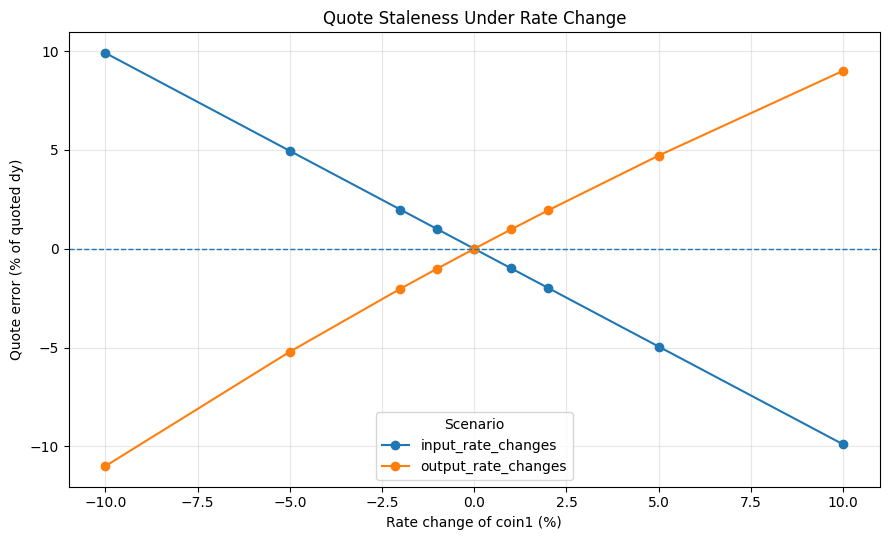

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for direction, group in plot_df.groupby("direction"):
    group = group.sort_values("rate_change_pct")
    ax.plot(
        group["rate_change_pct"],
        group["error_pct_display"],
        marker="o",
        label=direction,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Quote Staleness Under Rate Change")
ax.set_xlabel("Rate change of coin1 (%)")
ax.set_ylabel("Quote error (% of quoted dy)")
ax.legend(title="Scenario")
ax.grid(True, alpha=0.3)

figure_path = FIGURE_DIR / "quote_staleness_rate_change.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=160)

figure_path

PosixPath('/Users/chenxu/Work/artifacts/curve-stableswap-lab/outputs/figures/quote_staleness_abs_error.png')

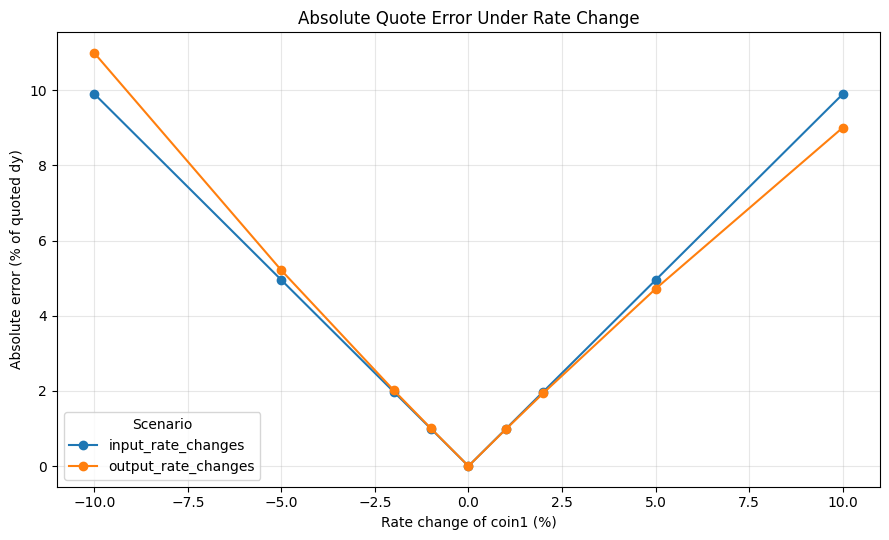

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for direction, group in plot_df.groupby("direction"):
    group = group.sort_values("rate_change_pct")
    ax.plot(
        group["rate_change_pct"],
        group["abs_error_pct_display"],
        marker="o",
        label=direction,
    )

ax.set_title("Absolute Quote Error Under Rate Change")
ax.set_xlabel("Rate change of coin1 (%)")
ax.set_ylabel("Absolute error (% of quoted dy)")
ax.legend(title="Scenario")
ax.grid(True, alpha=0.3)

figure_path = FIGURE_DIR / "quote_staleness_abs_error.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=160)

figure_path

In [11]:
plus_5 = plot_df[plot_df["rate_change"] == 1.05][
    [
        "direction",
        "rate_change",
        "quoted_dy",
        "executed_dy",
        "error",
        "error_pct_display",
    ]
]

plus_5

,direction,rate_change,quoted_dy,executed_dy,error,error_pct_display
14,output_rate_changes,1.05,999990099098224,952832340806449,47157758291775,4.715823
15,input_rate_changes,1.05,999990099098224,1049481725220628,-49491626122404,-4.949212


In [12]:
summary = (
    plot_df
    .groupby("direction")
    .agg(
        max_abs_error_pct=("abs_error_pct_display", "max"),
        mean_abs_error_pct=("abs_error_pct_display", "mean"),
        min_signed_error_pct=("error_pct_display", "min"),
        max_signed_error_pct=("error_pct_display", "max"),
    )
    .reset_index()
)

summary

,direction,max_abs_error_pct,mean_abs_error_pct,min_signed_error_pct,max_signed_error_pct
0,input_rate_changes,9.905606,3.960316,-9.895794,9.905606
1,output_rate_changes,10.994661,3.985241,-10.994661,9.004731


## Takeaways

The simulation shows that quote staleness is directional.

When coin1's rate changes after quote time:

1. If coin1 is the output token, a rate increase tends to make executed raw `dy` lower than the stale quote.
2. If coin1 is the input token, a rate increase tends to make executed raw output higher than the stale quote.
3. If the rate does not change, quoted and executed values match.
4. The quote was not "wrong" at quote time; it became stale because the economic meaning of one token changed before execution.

Security interpretation:

For StableSwap NG-style pools, quotes are only valid relative to the state used to compute:

```text
balances -> stored_rates -> xp -> D/y -> dy
```

If stored_rates can change between quote and execution, then quote freshness becomes a security and integration assumption.

This matters especially for:

- oracle-rate tokens;
- ERC4626 vault tokens;
- rebasing-aware integrations;
- routers or aggregators that cache quotes;
- protocols using pool quotes for collateral, minting, redemption, or liquidation logic.

The main audit lesson is:

A quote can be mathematically correct and still be economically stale.